# Phase 3 - HMMWV Basic Simulation

> Project Chrono / Vehicle / Wheeled  
> 목표: HMMWV + RigidTerrain 기본 주행, CSV 저장, 기본 그래프 생성

이 노트북은 Chrono 공식 `demo_VEH_HMMWV9_YUP.py` 구조를 프로젝트 실습용으로 줄인 버전이다.

핵심 흐름:

```text
HMMWV_Reduced 생성
→ RigidTerrain 생성
→ Interactive Driver 생성
→ Irrlicht Visualization 실행
→ Simulation Loop
→ 차량 상태 CSV 저장
→ speed-time, trajectory plot
```


## 1. Import

In [3]:
import os
import math as m
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pychrono as chrono
import pychrono.vehicle as veh
import pychrono.irrlicht as irr

print("Chrono import success")
print("NumPy version:", np.__version__)


Chrono import success
NumPy version: 1.26.4


## 2. Path and Output Setting

`results/phase3/` 폴더에 CSV와 그래프를 저장한다.  
Jupyter 실행 위치가 달라도 최대한 프로젝트 루트를 자동으로 찾도록 구성했다.


In [4]:
def find_project_root(start=None):
    """Find project root by searching upward for .git or docs folder."""
    if start is None:
        start = Path.cwd()
    start = Path(start).resolve()

    for p in [start] + list(start.parents):
        if (p / ".git").exists() or (p / "docs").exists():
            return p

    return start


PROJECT_ROOT = find_project_root()
RESULT_DIR = PROJECT_ROOT / "results" / "phase3"
FIGURE_DIR = RESULT_DIR / "figures"

RESULT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RESULT_DIR:", RESULT_DIR)
print("FIGURE_DIR:", FIGURE_DIR)


PROJECT_ROOT: C:\Project_Chrono\Project_Chrono_Practice
RESULT_DIR: C:\Project_Chrono\Project_Chrono_Practice\results\phase3
FIGURE_DIR: C:\Project_Chrono\Project_Chrono_Practice\results\phase3\figures


## 3. Simulation Parameters

초기 실험은 안정성을 위해 다음 조건을 사용한다.

| 항목 | 설정 |
|---|---|
| Vehicle | HMMWV_Reduced |
| World frame | Y-up |
| Terrain | Flat RigidTerrain |
| Tire | TMeasy |
| Visualization | Irrlicht |
| Simulation time | 20 s |


In [5]:
# Chrono Vehicle Y-up world frame
veh.ChWorldFrame.SetYUP()

# Initial vehicle location and orientation
# Y-up frame: X forward, Y up, Z right
initLoc = chrono.ChVector3d(0, 1, 10)
initYaw = 0.0

# Contact / tire / powertrain settings
contact_method = chrono.ChContactMethod_NSC
tire_model = veh.TireModelType_TMEASY

# Visualization type
chassis_vis_type = chrono.VisualizationType_PRIMITIVES
suspension_vis_type = chrono.VisualizationType_PRIMITIVES
steering_vis_type = chrono.VisualizationType_PRIMITIVES
wheel_vis_type = chrono.VisualizationType_MESH
tire_vis_type = chrono.VisualizationType_MESH

# Step sizes
step_size = 3e-3
tire_step_size = 1e-3

# End time
t_end = 20.0

# Terrain friction coefficient
terrain_friction = 0.9

print("Simulation parameters ready")


Simulation parameters ready


## 4. Helper Functions

차량 상태를 CSV에 저장하기 위한 보조 함수들이다.  
Chrono 버전별 API 차이를 줄이기 위해 `try/except`를 사용했다.


In [6]:
def get_chassis_body(hmmwv):
    """Return chassis body from HMMWV wrapper."""
    vehicle = hmmwv.GetVehicle()

    if hasattr(vehicle, "GetChassisBody"):
        return vehicle.GetChassisBody()

    if hasattr(vehicle, "GetChassis"):
        chassis = vehicle.GetChassis()
        if hasattr(chassis, "GetBody"):
            return chassis.GetBody()

    raise RuntimeError("Could not access chassis body. Check PyChrono vehicle API.")


def vec_to_tuple(v):
    """Convert Chrono vector-like object to tuple."""
    return (float(v.x), float(v.y), float(v.z))


def get_rpy_from_body(body):
    """Get roll, pitch, yaw from body rotation if API supports it."""
    rot = body.GetRot()

    try:
        angles = rot.GetCardanAnglesXYZ()
        return float(angles.x), float(angles.y), float(angles.z)
    except Exception:
        return np.nan, np.nan, np.nan


def get_vehicle_speed(hmmwv, body):
    """Get vehicle speed. Prefer vehicle API, fallback to velocity norm."""
    try:
        return float(hmmwv.GetVehicle().GetSpeed())
    except Exception:
        vel = body.GetPosDt()
        return float((vel.x**2 + vel.y**2 + vel.z**2) ** 0.5)


def log_vehicle_state(hmmwv, driver_inputs, case_name="hmmwv_basic"):
    """Collect one row of vehicle state."""
    system = hmmwv.GetSystem()
    body = get_chassis_body(hmmwv)

    time = float(system.GetChTime())
    pos = body.GetPos()
    vel = body.GetPosDt()
    roll, pitch, yaw = get_rpy_from_body(body)
    speed = get_vehicle_speed(hmmwv, body)

    return {
        "case_name": case_name,
        "time": time,

        # Y-up coordinate: x forward, y vertical, z lateral
        "x": float(pos.x),
        "y": float(pos.y),
        "z": float(pos.z),

        "vx": float(vel.x),
        "vy": float(vel.y),
        "vz": float(vel.z),

        "speed": speed,
        "roll": roll,
        "pitch": pitch,
        "yaw": yaw,

        "steering": float(driver_inputs.m_steering),
        "throttle": float(driver_inputs.m_throttle),
        "braking": float(driver_inputs.m_braking),
    }


print("Helper functions ready")


Helper functions ready


## 5. Vehicle Initialization

HMMWV reduced model을 생성한다.  
Reduced model은 full model보다 계산량이 작아서 Phase 3 초기 실험에 적합하다.


In [7]:
# Create HMMWV vehicle
hmmwv = veh.HMMWV_Reduced()

hmmwv.SetContactMethod(contact_method)
hmmwv.SetChassisCollisionType(veh.CollisionType_NONE)
hmmwv.SetChassisFixed(False)
hmmwv.SetInitPosition(chrono.ChCoordsysd(initLoc, chrono.QuatFromAngleY(initYaw)))

hmmwv.SetEngineType(veh.EngineModelType_SIMPLE)
hmmwv.SetTransmissionType(veh.TransmissionModelType_AUTOMATIC_SIMPLE_MAP)
hmmwv.SetDriveType(veh.DrivelineTypeWV_AWD)
hmmwv.SetTireType(tire_model)
hmmwv.SetTireStepSize(tire_step_size)

hmmwv.Initialize()

# Visualization setting for vehicle parts
hmmwv.SetChassisVisualizationType(chassis_vis_type)
hmmwv.SetSuspensionVisualizationType(suspension_vis_type)
hmmwv.SetSteeringVisualizationType(steering_vis_type)
hmmwv.SetWheelVisualizationType(wheel_vis_type)
hmmwv.SetTireVisualizationType(tire_vis_type)

# Collision system
hmmwv.GetSystem().SetCollisionSystemType(chrono.ChCollisionSystem.Type_BULLET)

print("HMMWV initialized")


HMMWV initialized


## 6. Terrain Initialization

평탄한 `RigidTerrain`을 생성한다.


In [8]:
terrain = veh.RigidTerrain(hmmwv.GetSystem())

patch_mat = chrono.ChContactMaterialNSC()
patch_mat.SetFriction(terrain_friction)

# In Y-up world frame, rotate terrain patch so it becomes horizontal.
patch = terrain.AddPatch(
    patch_mat,
    chrono.ChCoordsysd(chrono.VNULL, chrono.QuatFromAngleX(-m.pi / 2)),
    200.0,
    100.0
)

patch.SetTexture(veh.GetVehicleDataFile("terrain/textures/tile4.jpg"), 200, 200)
patch.SetColor(chrono.ChColor(0.8, 0.8, 0.5))

terrain.Initialize()

print("RigidTerrain initialized")


RigidTerrain initialized


## 7. Driver and Visualization

키보드로 조향/가속/제동을 입력할 수 있는 interactive driver를 사용한다.

기본 키 조작은 Chrono 예제와 동일하다.

```text
W : 가속 / throttle 증가
S : 감속 / brake 증가
A : 왼쪽 조향
D : 오른쪽 조향
J : 현재 driver input lock/unlock
```


In [9]:
# Interactive driver
driver = veh.ChInteractiveDriver(hmmwv.GetVehicle())

driver.SetSteeringDelta(0.06)
driver.SetThrottleDelta(0.02)
driver.SetBrakingDelta(0.06)
driver.Initialize()

# Irrlicht visualization
vis = veh.ChWheeledVehicleVisualSystemIrrlicht()
vis.SetCameraVertical(chrono.CameraVerticalDir_Y)
vis.SetWindowTitle("Phase3 - HMMWV Basic")
vis.SetWindowSize(1280, 900)
vis.SetChaseCamera(chrono.ChVector3d(0.0, 0.0, 0.75), 6.0, 0.5)

vis.Initialize()
vis.AddLogo(chrono.GetChronoDataFile("logo_chrono_alpha.png"))
vis.AddLightDirectional(-60, 300)
vis.AddSkyBox()

vis.AttachVehicle(hmmwv.GetVehicle())
vis.AttachDriver(driver)

hmmwv.GetVehicle().EnableRealtime(True)

print("Driver and visualization initialized")



# ==========================================================================
# Simulation loop
# ==========================================================================

# ==========================================================================
# Safe Simulation loop with periodic CSV checkpoint
# ==========================================================================

log_rows = []

csv_path = RESULT_DIR / "hmmwv_basic_log_autosave.csv"
checkpoint_interval = 100   # 100 step마다 저장

print("Simulation started")
print("Click the Irrlicht window, then use W/A/S/D.")
print("Autosave path:", csv_path)
print("Close the Irrlicht window or wait until t_end =", t_end, "s")

try:
    while vis.Run():
        time = hmmwv.GetSystem().GetChTime()

        if time >= t_end:
            break

        # Render
        vis.BeginScene()
        vis.Render()
        vis.EndScene()

        # Get driver inputs
        driver_inputs = driver.GetInputs()

        # Log current vehicle state
        row = log_vehicle_state(hmmwv, driver_inputs, case_name="hmmwv_basic")
        log_rows.append(row)

        # Periodic autosave
        if len(log_rows) % checkpoint_interval == 0:
            df_temp = pd.DataFrame(log_rows)
            df_temp.to_csv(csv_path, index=False, encoding="utf-8-sig")
            print(f"Autosaved {len(log_rows)} rows at t = {time:.2f} s")

        # Synchronize modules
        driver.Synchronize(time)
        terrain.Synchronize(time)
        hmmwv.Synchronize(time, driver_inputs, terrain)
        vis.Synchronize(time, driver_inputs)

        # Advance simulation
        driver.Advance(step_size)
        terrain.Advance(step_size)
        hmmwv.Advance(step_size)
        vis.Advance(step_size)

except KeyboardInterrupt:
    print("Simulation interrupted by user.")

except Exception as e:
    print("Simulation stopped due to error:")
    print(e)

finally:
    if len(log_rows) > 0:
        df = pd.DataFrame(log_rows)
        df.to_csv(csv_path, index=False, encoding="utf-8-sig")
        print("Final autosave completed.")
        print("Saved rows:", len(log_rows))
        print("Saved CSV:", csv_path)
    else:
        print("No data was logged.")

print("Simulation finished")


'''ArithmeticError
log_rows = []

print("Simulation started")
print("Close the Irrlicht window or wait until t_end =", t_end, "s")

while vis.Run():
    time = hmmwv.GetSystem().GetChTime()

    # Stop automatically after t_end
    if time >= t_end:
        break

    # Render
    vis.BeginScene()
    vis.Render()
    vis.EndScene()

    # Get driver inputs
    driver_inputs = driver.GetInputs()

    # Log current vehicle state
    log_rows.append(log_vehicle_state(hmmwv, driver_inputs, case_name="hmmwv_basic"))

    # Synchronize modules
    driver.Synchronize(time)
    terrain.Synchronize(time)
    hmmwv.Synchronize(time, driver_inputs, terrain)
    vis.Synchronize(time, driver_inputs)

    # Advance simulation
    driver.Advance(step_size)
    terrain.Advance(step_size)
    hmmwv.Advance(step_size)
    vis.Advance(step_size)

print("Simulation finished")
print("Number of logged rows:", len(log_rows))

while vis.Run():
    time = hmmwv.GetSystem().GetChTime()

    vis.BeginScene()
    vis.Render()
    vis.EndScene()

    driver_inputs = driver.GetInputs()

    driver.Synchronize(time)
    terrain.Synchronize(time)
    hmmwv.Synchronize(time, driver_inputs, terrain)
    vis.Synchronize(time, driver_inputs)

    driver.Advance(step_size)
    terrain.Advance(step_size)
    hmmwv.Advance(step_size)
    vis.Advance(step_size)

    if time > 20:
        break
'''

Driver and visualization initialized
Simulation started
Click the Irrlicht window, then use W/A/S/D.
Autosave path: C:\Project_Chrono\Project_Chrono_Practice\results\phase3\hmmwv_basic_log_autosave.csv
Close the Irrlicht window or wait until t_end = 20.0 s
Autosaved 100 rows at t = 0.30 s
Autosaved 200 rows at t = 0.60 s
Autosaved 300 rows at t = 0.90 s
Autosaved 400 rows at t = 1.20 s
Autosaved 500 rows at t = 1.50 s
Autosaved 600 rows at t = 1.80 s
Autosaved 700 rows at t = 2.10 s
Autosaved 800 rows at t = 2.40 s
Autosaved 900 rows at t = 2.70 s
Autosaved 1000 rows at t = 3.00 s
Autosaved 1100 rows at t = 3.30 s
Autosaved 1200 rows at t = 3.60 s
Autosaved 1300 rows at t = 3.90 s
Autosaved 1400 rows at t = 4.20 s
Autosaved 1500 rows at t = 4.50 s
Autosaved 1600 rows at t = 4.80 s
Autosaved 1700 rows at t = 5.10 s
Autosaved 1800 rows at t = 5.40 s
Autosaved 1900 rows at t = 5.70 s
Autosaved 2000 rows at t = 6.00 s
Autosaved 2100 rows at t = 6.30 s
Autosaved 2200 rows at t = 6.60 s
Auto

'ArithmeticError\nlog_rows = []\n\nprint("Simulation started")\nprint("Close the Irrlicht window or wait until t_end =", t_end, "s")\n\nwhile vis.Run():\n    time = hmmwv.GetSystem().GetChTime()\n\n    # Stop automatically after t_end\n    if time >= t_end:\n        break\n\n    # Render\n    vis.BeginScene()\n    vis.Render()\n    vis.EndScene()\n\n    # Get driver inputs\n    driver_inputs = driver.GetInputs()\n\n    # Log current vehicle state\n    log_rows.append(log_vehicle_state(hmmwv, driver_inputs, case_name="hmmwv_basic"))\n\n    # Synchronize modules\n    driver.Synchronize(time)\n    terrain.Synchronize(time)\n    hmmwv.Synchronize(time, driver_inputs, terrain)\n    vis.Synchronize(time, driver_inputs)\n\n    # Advance simulation\n    driver.Advance(step_size)\n    terrain.Advance(step_size)\n    hmmwv.Advance(step_size)\n    vis.Advance(step_size)\n\nprint("Simulation finished")\nprint("Number of logged rows:", len(log_rows))\n\nwhile vis.Run():\n    time = hmmwv.GetSystem(

## 8. Simulation Loop and CSV Logging

Irrlicht 창이 열리면 차량을 조작할 수 있다.  
`t_end`에 도달하거나 창을 닫으면 simulation이 종료되고 CSV가 저장된다.

(위 코드 simulation loop 부분에 해당함)


## 9. Save CSV

In [10]:
df = pd.DataFrame(log_rows)

csv_path = RESULT_DIR / "hmmwv_basic_log.csv"
df.to_csv(csv_path, index=False, encoding="utf-8-sig")

print("Saved CSV:", csv_path)
display(df.head())
display(df.tail())


Saved CSV: C:\Project_Chrono\Project_Chrono_Practice\results\phase3\hmmwv_basic_log.csv


,case_name,time,x,y,z,vx,vy,vz,speed,roll,pitch,yaw,steering,throttle,braking
0,hmmwv_basic,0.000,0.056000,1.213000,10.0,0.000000,0.000000,0.000000e+00,0.000000,-1.570796,0.000000e+00,0.000000,0.0,0.0,0.0
1,hmmwv_basic,0.003,0.056006,1.212908,10.0,0.001975,-0.030634,-6.863038e-07,-0.004053,-1.570797,-7.627943e-10,-0.000085,0.0,0.0,0.0
2,hmmwv_basic,0.006,0.056013,1.212716,10.0,0.002207,-0.063879,-2.397985e-06,-0.004182,-1.570797,-1.722348e-09,-0.000175,0.0,0.0,0.0
3,hmmwv_basic,0.009,0.056019,1.212433,10.0,0.002232,-0.094359,-2.632355e-06,-0.004127,-1.570797,-2.230584e-09,-0.000265,0.0,0.0,0.0
4,hmmwv_basic,0.012,0.056026,1.212061,10.0,0.002198,-0.124061,-2.645387e-06,-0.004017,-1.570797,-2.553767e-09,-0.000353,0.0,0.0,0.0


,case_name,time,x,y,z,vx,vy,vz,speed,roll,pitch,yaw,steering,throttle,braking
6662,hmmwv_basic,19.986,49.781924,0.635798,-16.778975,7.529353,0.002752,7.773968,10.775762,-1.558630,-0.885498,-0.035916,-1.0,0.128099,0.306418
6663,hmmwv_basic,19.989,49.804440,0.635806,-16.755639,7.505292,0.002757,7.778430,10.762008,-1.558436,-0.887685,-0.036077,-1.0,0.126568,0.311361
6664,hmmwv_basic,19.992,49.826883,0.635814,-16.732291,7.481166,0.002764,7.782677,10.748086,-1.558239,-0.889873,-0.036238,-1.0,0.125055,0.316245
6665,hmmwv_basic,19.995,49.849254,0.635822,-16.708931,7.456985,0.002778,7.786739,10.734030,-1.558041,-0.892061,-0.036401,-1.0,0.123560,0.321071
6666,hmmwv_basic,19.998,49.871553,0.635831,-16.685559,7.432747,0.002790,7.790583,10.719808,-1.557840,-0.894249,-0.036566,-1.0,0.122084,0.325839


## 10. Plot Results

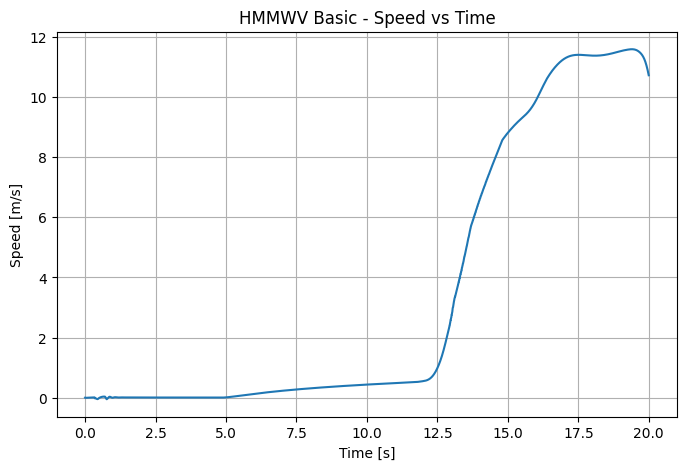

Saved figure: C:\Project_Chrono\Project_Chrono_Practice\results\phase3\figures\hmmwv_basic_speed.png


In [11]:
if len(df) > 0:
    plt.figure(figsize=(8, 5))
    plt.plot(df["time"], df["speed"])
    plt.xlabel("Time [s]")
    plt.ylabel("Speed [m/s]")
    plt.title("HMMWV Basic - Speed vs Time")
    plt.grid(True)

    speed_fig_path = FIGURE_DIR / "hmmwv_basic_speed.png"
    plt.savefig(speed_fig_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved figure:", speed_fig_path)
else:
    print("No data to plot")


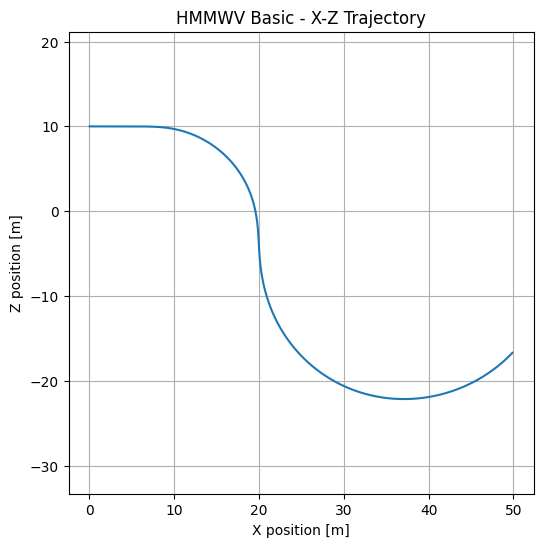

Saved figure: C:\Project_Chrono\Project_Chrono_Practice\results\phase3\figures\hmmwv_basic_trajectory.png


In [12]:
if len(df) > 0:
    plt.figure(figsize=(6, 6))
    plt.plot(df["x"], df["z"])
    plt.xlabel("X position [m]")
    plt.ylabel("Z position [m]")
    plt.title("HMMWV Basic - X-Z Trajectory")
    plt.axis("equal")
    plt.grid(True)

    traj_fig_path = FIGURE_DIR / "hmmwv_basic_trajectory.png"
    plt.savefig(traj_fig_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved figure:", traj_fig_path)
else:
    print("No data to plot")


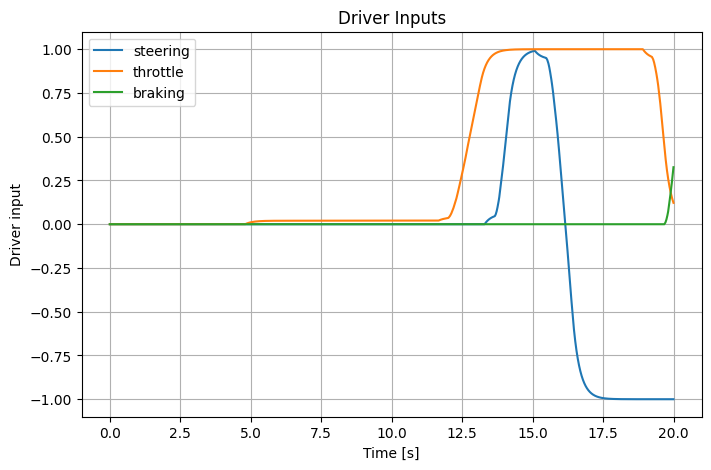

Saved figure: C:\Project_Chrono\Project_Chrono_Practice\results\phase3\figures\hmmwv_basic_driver_inputs.png


In [13]:
if len(df) > 0:
    plt.figure(figsize=(8, 5))
    plt.plot(df["time"], df["steering"], label="steering")
    plt.plot(df["time"], df["throttle"], label="throttle")
    plt.plot(df["time"], df["braking"], label="braking")
    plt.xlabel("Time [s]")
    plt.ylabel("Driver input")
    plt.title("Driver Inputs")
    plt.grid(True)
    plt.legend()

    input_fig_path = FIGURE_DIR / "hmmwv_basic_driver_inputs.png"
    plt.savefig(input_fig_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved figure:", input_fig_path)
else:
    print("No data to plot")


## 11. Quick Analysis

아래 셀은 기본 성능 지표를 계산한다.


In [ ]:
if len(df) > 0:
    summary = {
        "simulation_time_s": float(df["time"].max() - df["time"].min()),
        "final_x_m": float(df["x"].iloc[-1]),
        "final_z_m": float(df["z"].iloc[-1]),
        "travel_distance_x_m": float(df["x"].iloc[-1] - df["x"].iloc[0]),
        "mean_speed_mps": float(df["speed"].mean()),
        "max_speed_mps": float(df["speed"].max()),
        "max_abs_roll_rad": float(df["roll"].abs().max()) if "roll" in df else np.nan,
        "max_abs_pitch_rad": float(df["pitch"].abs().max()) if "pitch" in df else np.nan,
        "max_abs_yaw_rad": float(df["yaw"].abs().max()) if "yaw" in df else np.nan,
    }

    summary_df = pd.DataFrame([summary])
    summary_path = RESULT_DIR / "hmmwv_basic_summary.csv"
    summary_df.to_csv(summary_path, index=False, encoding="utf-8-sig")

    print("Saved summary:", summary_path)
    display(summary_df)
else:
    print("No data to summarize")


Saved summary: C:\Project_Chrono\Project_Chrono_Practice\results\phase3\hmmwv_basic_summary.csv


,simulation_time_s,final_x_m,final_z_m,travel_distance_x_m,mean_speed_mps,max_speed_mps,max_abs_roll_rad,max_abs_pitch_rad,max_abs_yaw_rad
0,19.998,49.871553,-16.685559,49.815553,3.518683,11.585246,2.459698,1.54725,0.890374


: 

## 12. Interpretation Template

실험 후 아래 내용을 채우면 `docs/vehicle/wheeled/experiment_plan.md` 또는 별도 결과 문서에 옮기기 쉽다.

```text
1. 차량은 정상적으로 전진했는가?
2. speed-time 그래프에서 가속 구간과 정상 상태가 보이는가?
3. steering = 0일 때 x-z trajectory가 거의 직선인가?
4. throttle 입력 변화가 speed 변화와 일치하는가?
5. 다음 실험에서 바꿀 변수는 무엇인가?
```
